**TFM - Sistema detector de fraude en transacciones financieras mediante el uso del aprendizaje automático**

Lo primero ha realizar, es la descarga del dataset con el que se va a realizar el trabajo.

In [2]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /Users/alvaro/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [3]:
import os
import pandas as pd

# Compruebo que el archivo en el que voy a trabajar está dentro de la carpeta
print(os.listdir(path))

['creditcard.csv']


In [4]:
# Ruta al CSV
csv_path = os.path.join(path, "creditcard.csv")

# Cargo el dataset
df = pd.read_csv(csv_path)

# Muestro las 5 primeras filas
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**1. Análisis exploratorio inicial (EDA)**

El objetivo del EDA es poder entender el dataset, demostrar si hay o no desbalanceo y generar unas primeras métricas para la memoria del trabajo.

In [5]:
# Dimensiones del dataset

print("Número de filas y columnas:")
print(df.shape)

Número de filas y columnas:
(284807, 31)


In [6]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Compruebo si existen valores nulos

print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
# Distribución de clases

# El significado de 'Class' = 0 -> Transacción legítima
# El significado de 'Class' = 1 -> Transacción fraudulenta
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# Porcentaje de fraude
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100

print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.4f}%")

Porcentaje de transacciones fraudulentas: 0.1727%


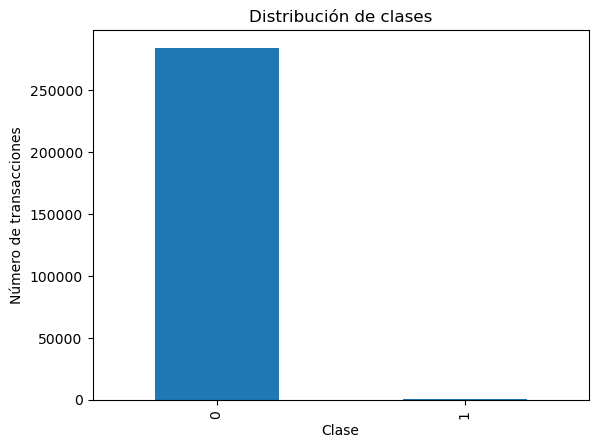

In [10]:
import matplotlib.pyplot as plt

# Distribución de clases con una representacion gráfica
df['Class'].value_counts().plot(kind='bar')

plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Número de transacciones')

plt.show()

**2. Preprocesado + Train/Test Split**

El objetivo aquí es poder separar variables, dividir train/test y preparar datos para ML.

In [11]:
# Variables predictoras

# El significado de 'X' -> características/transacciones
X = df.drop('Class', axis=1)

# Variable objetivo

# El significado de 'y' -> fraude o no fraude
y = df['Class']

In [12]:
from sklearn.model_selection import train_test_split

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #Mantiene el porcentaje de fraude en train y en test
)

# Mostrar tamaños
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (227845, 30)
Test: (56962, 30)


Distribución original:
Class
0    227451
1       394
Name: count, dtype: int64

Distribución tras SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


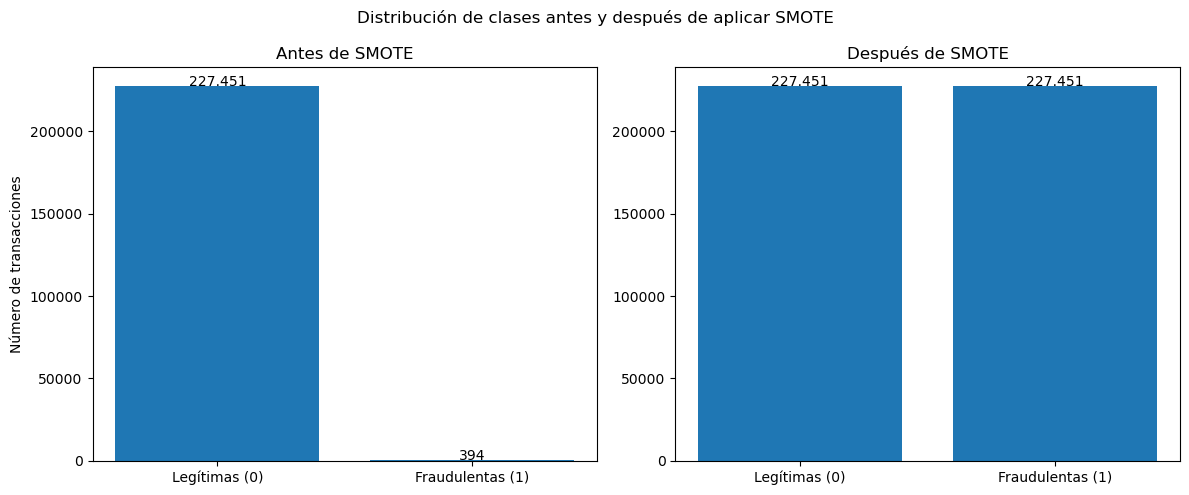

In [13]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Ver nueva distribución
print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución tras SMOTE:")
print(y_train_smote.value_counts())

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Antes de SMOTE
antes = [227451, 394]

ax[0].bar(
    ["Legítimas (0)", "Fraudulentas (1)"],
    antes
)

ax[0].set_title("Antes de SMOTE")
ax[0].set_ylabel("Número de transacciones")

for i, v in enumerate(antes):
    ax[0].text(i, v, f"{v:,}".replace(",", "."), ha="center")

# Después de SMOTE
despues = [227451, 227451]

ax[1].bar(
    ["Legítimas (0)", "Fraudulentas (1)"],
    despues
)

ax[1].set_title("Después de SMOTE")

for i, v in enumerate(despues):
    ax[1].text(i, v, f"{v:,}".replace(",", "."), ha="center")

plt.suptitle("Distribución de clases antes y después de aplicar SMOTE")

plt.tight_layout()

plt.show()

**¿Por qué aplico SMOTE?**

SMOTE (Synthetic Minority Over-sampling Technique) es una técnica utilizada para abordar problemas de desbalanceo de clases en conjuntos de datos. En el contexto de la detección de fraude financiero, las transacciones fraudulentas representan una proporción muy reducida respecto al total de operaciones legítimas, lo que puede provocar que los modelos de aprendizaje automático favorezcan la clase mayoritaria y reduzcan su capacidad para detectar fraude.

Para mitigar este problema, SMOTE genera ejemplos sintéticos de la clase minoritaria a partir de los datos existentes, equilibrando así la distribución de clases en el conjunto de entrenamiento. De este modo, se busca mejorar la capacidad de los modelos para identificar correctamente las transacciones fraudulentas.

**3. Modelo de Regresión Logística**

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Creo el escalador
scaler = StandardScaler()

# Escalo datos
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Creo el modelo
log_model = LogisticRegression(max_iter=2000)

# Entreno modelo
log_model.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=2000)

El modelo aprende patrones legítimos y patrones fraudulentos usando datos balanceados con SMOTE

In [36]:
from sklearn.metrics import classification_report

# Predicciones
y_pred = log_model.predict(X_test_scaled)

# Métricas
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



**Precision indica:** cuántos fraudes detectados eran realmente fraude

**Recall indica:** cuántos fraudes reales detectó

**F1-score indica:** equilibrio entre precision y recall

Los resultados obtenidos mediante regresión logística muestran un valor elevado de recall en la detección de fraude, alcanzando aproximadamente un 90%, lo que indica una alta capacidad del modelo para identificar transacciones fraudulentas. Sin embargo, la precisión obtenida es reducida, lo que implica la aparición de un número considerable de falsos positivos. Este comportamiento resulta habitual en problemas altamente desbalanceados y refleja el compromiso existente entre maximizar la detección de fraude y minimizar las falsas alarmas.

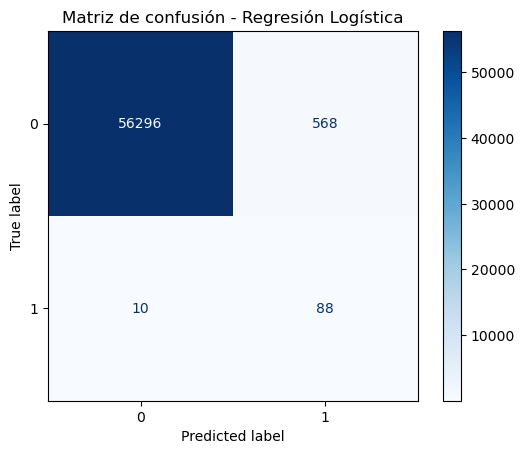

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Creo la matriz
cm = confusion_matrix(y_test, y_pred)

# Muestro la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Matriz de confusión - Regresión Logística")

plt.show()

La matriz de confusión obtenida muestra que el modelo de regresión logística fue capaz de detectar correctamente un elevado número de transacciones fraudulentas, reduciendo significativamente los falsos negativos. Esto resulta especialmente relevante en problemas de fraude financiero, donde la detección de operaciones fraudulentas es prioritaria frente a la minimización de falsos positivos.

**4. Modelo con Random Forest**

In [38]:
from sklearn.ensemble import RandomForestClassifier

# Creo modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entreno el modelo
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [39]:
from sklearn.metrics import classification_report

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



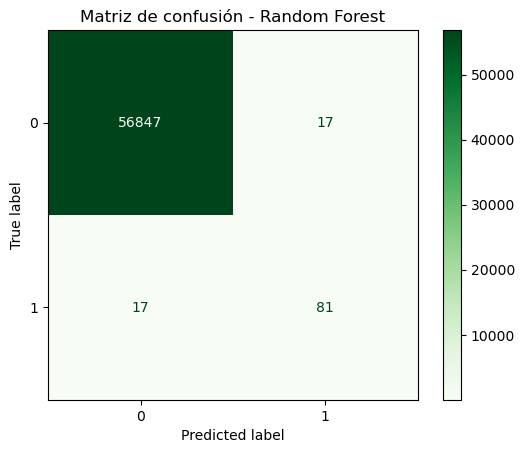

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Greens')
plt.title("Matriz de confusión - Random Forest")
plt.show()

Los resultados obtenidos muestran diferencias significativas entre los modelos evaluados. La regresión logística presentó un valor elevado de recall, detectando aproximadamente el 90% de las transacciones fraudulentas, aunque con una precisión reducida debido al elevado número de falsos positivos generados.

Por otro lado, el modelo Random Forest obtuvo un comportamiento más equilibrado, alcanzando valores cercanos al 83% tanto en precisión como en recall. Esto indica una mejor capacidad para detectar fraude reduciendo simultáneamente el número de falsas alarmas, lo que lo convierte en una alternativa más robusta para este tipo de problemas.

**5. Modelo con XGBoost**

In [41]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Creo objeto SMOTE
smote = SMOTE(random_state=42)

# Aplico SMOTE al conjunto de entrenamiento
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Muestro nueva distribución
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [42]:
# Se crea el modelo
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [43]:
# Entrenamiento del modelo
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
# Realizar predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Mostrar métricas
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



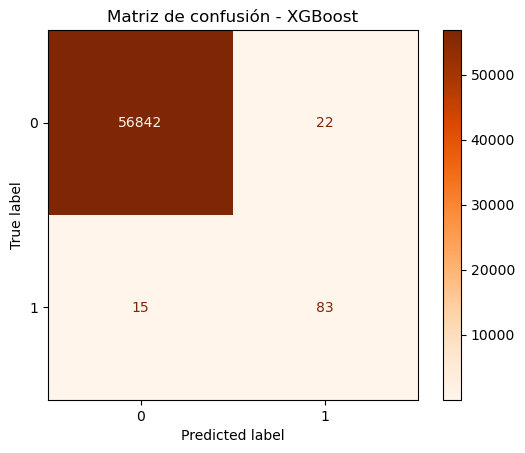

In [45]:
# Creo la matriz de confusión 
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Muestro la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)

disp.plot(cmap='Oranges')
plt.title("Matriz de confusión - XGBoost")
plt.show()

**6. Modelo LightGBM**:

Con el objetivo de evaluar una técnica más reciente utilizada en problemas de clasificación sobre datos, se incorpora el algoritmo LightGBM. Este método pertenece a la familia de los algoritmos de boosting y ha demostrado obtener resultados competitivos en problemas de detección de fraude y clasificación desbalanceada.

In [47]:
# Instalación de la librería

!pip install lightgbm

In [49]:
from lightgbm import LGBMClassifier

# Creamos el modelo LightGBM
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

# Entrenamiento del modelo
lgbm_model.fit(X_train_smote, y_train_smote)

LGBMClassifier(random_state=42, verbose=-1)

In [50]:
from sklearn.metrics import classification_report

# Realizamos las predicciones
y_pred_lgbm = lgbm_model.predict(X_test)

# Métricas 
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.81      0.69        98

    accuracy                           1.00     56962
   macro avg       0.80      0.90      0.84     56962
weighted avg       1.00      1.00      1.00     56962



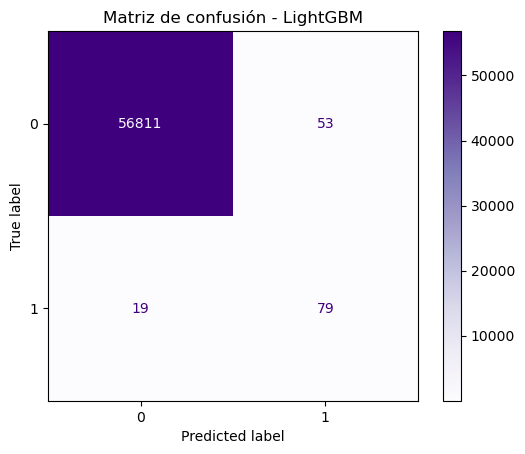

In [51]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm)

disp.plot(cmap="Purples")

plt.title("Matriz de confusión - LightGBM")

plt.show()

**7. Evaluación comparativa de modelos**

Con el objetivo de comparar el rendimiento de los distintos modelos evaluados, se resumen las principales métricas obtenidas en la Tabla 1.

Las métricas seleccionadas son precisión (Precision), capacidad de detección (Recall) y F1-score, ya que resultan más representativas que la exactitud en problemas con fuerte desbalanceo de clases.

In [54]:
results = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Precision": [
        0.13,
        0.83,
        0.79,
        0.60
    ],
    "Recall": [
        0.90,
        0.83,
        0.85,
        0.81
    ],
    "F1-Score": [
        0.23,
        0.83,
        0.82,
        0.69
    ]
})

results

,Modelo,Precision,Recall,F1-Score
0,Regresión Logística,0.13,0.90,0.23
1,Random Forest,0.83,0.83,0.83
2,XGBoost,0.79,0.85,0.82
3,LightGBM,0.60,0.81,0.69


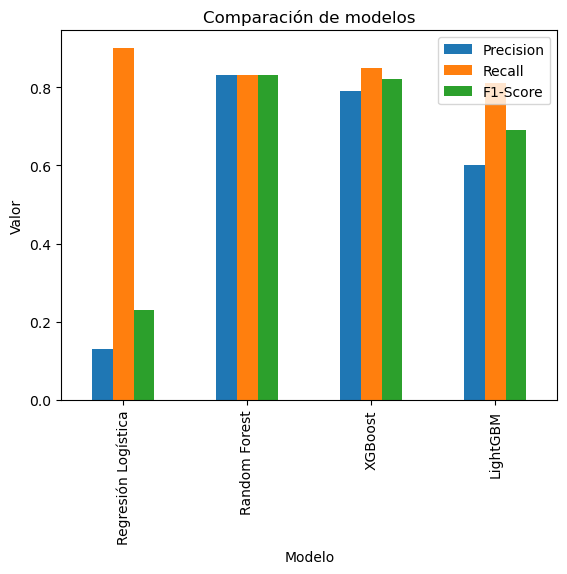

In [55]:
results.plot(

    x="Modelo",

    y=["Precision","Recall","F1-Score"],

    kind="bar"

)

plt.title("Comparación de modelos")

plt.ylabel("Valor")

plt.show()

**Resultado final de los modelos evaluados**

Los resultados obtenidos muestran diferencias relevantes entre los distintos modelos de aprendizaje automático evaluados. La regresión logística presentó el mayor valor de recall (0.90), siendo capaz de detectar la mayoría de las transacciones fraudulentas. Sin embargo, su precisión fue muy reducida (0.13), lo que implica un elevado número de falsos positivos.

Los modelos basados en árboles de decisión y técnicas de boosting ofrecieron un comportamiento más equilibrado. Random Forest obtuvo los mejores resultados globales, alcanzando valores próximos al 83% tanto en precisión como en recall, además de presentar el mejor equilibrio entre detección de fraude y reducción de falsas alarmas.

XGBoost mostró un rendimiento muy similar, con un recall ligeramente superior (0.85) pero una precisión algo inferior (0.79). Por su parte, LightGBM obtuvo resultados aceptables, aunque inferiores a los de Random Forest y XGBoost para este conjunto de datos, alcanzando un F1-score de 0.69.

En conjunto, los resultados evidencian la importancia de comparar distintos modelos en problemas de detección de fraude financiero. Para el conjunto de datos utilizado en este trabajo, Random Forest se presenta como la alternativa más equilibrada y adecuada entre los modelos evaluados.